In [19]:
# import packages and BTMS_model

import os
import sys
import io
import contextlib
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from openpyxl import load_workbook
from openpyxl.styles import Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter

PROJECT_ROOT = os.path.abspath("../..")
sys.path.append(PROJECT_ROOT)

import lib.BTMS_model as BTMS_model
import CoolProp.CoolProp as CP


In [20]:
# result-file naming configuration
# This notebook runs one fixed Park air-cooling validation case and plots
# the maximum and minimum cell temperatures over the complete mission.

CASE_ID = 'C0008'
REVISION = 'R00'
RESULT_ID = f'{CASE_ID}{REVISION}'

SCENARIO_CODE = 'PARK25'
BTMS_CODE = 'AC'
MODEL_CODE = '1D'
TASK_CODE = 'VAL'

RESULT_BASENAME = f'{RESULT_ID}_{SCENARIO_CODE}_{BTMS_CODE}_{MODEL_CODE}_{TASK_CODE}'
OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'out', CASE_ID)
RESULT_FIGURE_NAME = f'{RESULT_BASENAME}.png'


# CFD validation data: maximum and minimum volume-averaged cell temperatures
CFD_FOLDER_NAME = (
    'HP02E030113A2  result_T_peak_avg per bat cell_'
    'air cooling_CFD_val_Liu_20260723'
)
CFD_DATA_DIR = os.path.join(
    PROJECT_ROOT,
    'data',
    CFD_FOLDER_NAME
)

print(f'Result basename: {RESULT_BASENAME}')
print(f'Temperature-curve figure: {RESULT_FIGURE_NAME}')


Result basename: C0008R00_PARK25_AC_1D_VAL
Temperature-curve figure: C0008R00_PARK25_AC_1D_VAL.png


In [21]:
# read Qbat(W) from the data file

# Keep the physical simulation duration unchanged, while using the original time step.
SIM_DURATION_S = 1920.0   # s, physical mission duration
dt = 1.0                 # s, integration time step

NUM_STEPS = int(round(SIM_DURATION_S / dt))
if not np.isclose(NUM_STEPS * dt, SIM_DURATION_S):
    raise ValueError('SIM_DURATION_S must be an integer multiple of dt.')

# Keep the original variable name for downstream compatibility.
# Here SIM_TIME_S means the number of numerical time steps, not the physical duration.
SIM_TIME_S = NUM_STEPS

file_name = os.path.join(
    PROJECT_ROOT,
    'data',
    'MD05E070207A1  data_power gen_single cell_Liu_20260421.xlsx'
)

df = pd.read_excel(file_name, sheet_name='Sheet1')
power_generation_data_1s = df['Qbat(W)'].dropna().to_numpy(dtype=float)

if len(power_generation_data_1s) == 0:
    raise ValueError('The Qbat(W) column does not contain valid heat-generation data.')

# The source Qbat data are treated as 1-s samples. For dt = 1.0 s,
# each 1-s heat-generation value is used for one numerical time step.
time_s = np.arange(SIM_TIME_S + 1) * dt
power_indices = np.floor(time_s[:-1]).astype(int)
power_indices = np.clip(power_indices, 0, len(power_generation_data_1s) - 1)
power_generation_data = power_generation_data_1s[power_indices]

print(f'Simulation duration: {SIM_DURATION_S:.1f} s')
print(f'Time step dt: {dt:.3f} s')
print(f'Number of numerical steps: {SIM_TIME_S}')
print(f'Q_gen array length: {len(power_generation_data)}')


Simulation duration: 1920.0 s
Time step dt: 1.000 s
Number of numerical steps: 1920
Q_gen array length: 1920


In [22]:
# model settings and fixed validation-case parameters

# battery cell properties
BATTERY_PROPS = {
    'm_bat': 48e-3,          # kg
    'cp_bat': 830.0,         # J/(kg K)
    'D_bat': 18e-3,          # m
    'H_bat': 65e-3,          # m
}

# 1D module layout
MODULE_LAYOUT = {
    'N_r': 16,               # number of cells in the transverse direction
    'N_c': 20,               # number of cells along the air-flow direction
    'num_cell_seg': 1.0,     # number of cells represented by each battery segment
}

# coolant / air settings
AIR_SETTINGS = {
    'fluid': 'Air',
    'p_air': 101325.0,       # Pa
}

# air-cooling operating period
# 0-180 s: no air cooling
# 180-1560 s: air cooling
# 1560-1920 s: no air cooling
COOLING_PERIOD = {
    't_cruise_start': 180.0,
    't_cruise_end': 1560.0,
}

# solver settings passed to BTMS_model.solve_coolant_temperature_distribution
SOLVER_SETTINGS = {
    'solver_tol': 1e-6,
    'solver_maxiter': 1000,
}

# Fixed air-cooling validation condition
VALIDATION_CASE = {
    'case_id': RESULT_ID,
    'V_air': 4.0,            # m/s during the cooling period
    'T_air': 20.0,           # degC
    's_gap_mm': 3.0,         # mm
}

# Keep original variable names for the calculation section.
m_bat = BATTERY_PROPS['m_bat']
cp_bat = BATTERY_PROPS['cp_bat']
D_bat = BATTERY_PROPS['D_bat']
H_bat = BATTERY_PROPS['H_bat']
A_battery = np.pi * D_bat * H_bat

N_r = MODULE_LAYOUT['N_r']
N_c = MODULE_LAYOUT['N_c']
num_seg = N_c
num_cell_seg = MODULE_LAYOUT['num_cell_seg']

fluid = AIR_SETTINGS['fluid']
p_air = AIR_SETTINGS['p_air']

t_cruise_start = COOLING_PERIOD['t_cruise_start']
t_cruise_end = COOLING_PERIOD['t_cruise_end']

solver_tol = SOLVER_SETTINGS['solver_tol']
solver_maxiter = SOLVER_SETTINGS['solver_maxiter']

case_id = VALIDATION_CASE['case_id']
V_air = float(VALIDATION_CASE['V_air'])
T_air = float(VALIDATION_CASE['T_air'])
s_gap_mm = float(VALIDATION_CASE['s_gap_mm'])

print('Fixed validation case:')
print(f'  case_id = {case_id}')
print(f'  V_air = {V_air:.3f} m/s during cruise')
print(f'  T_air = {T_air:.3f} degC')
print(f'  s_gap = {s_gap_mm:.3f} mm')


Fixed validation case:
  case_id = C0008R00
  V_air = 4.000 m/s during cruise
  T_air = 20.000 degC
  s_gap = 3.000 mm


In [23]:
# calculate the fixed inlet-air properties once

T_air_K = T_air + 273.15

mu_air = CP.PropsSI('V', 'T', T_air_K, 'P', p_air, fluid)
rho_air = CP.PropsSI('D', 'T', T_air_K, 'P', p_air, fluid)
cp_air = CP.PropsSI('C', 'T', T_air_K, 'P', p_air, fluid)
k_air = CP.PropsSI('L', 'T', T_air_K, 'P', p_air, fluid)
Pr_air = cp_air * mu_air / k_air

air_props = {
    'mu_air': mu_air,
    'rho_air': rho_air,
    'cp_air': cp_air,
    'k_air': k_air,
    'Pr_air': Pr_air,
}

print('Air properties calculated for the fixed inlet condition.')


Air properties calculated for the fixed inlet condition.


In [24]:
# run the single Park air-cooling validation case by calling BTMS_model

def run_validation_case(case_id, V_air, T_air, s_gap_mm):
    # ---------------------------------------------------------
    # Fixed validation geometry
    # ---------------------------------------------------------
    s_gap = s_gap_mm * 1e-3

    # Cell pitches along and perpendicular to the airflow
    S_L = D_bat + s_gap
    S_T = D_bat + s_gap

    # Full-module inlet area and one representative airflow-domain area
    W_module = D_bat + (N_r - 1) * S_T
    A_air = W_module * H_bat
    A_cool = A_air / N_r

    # Heat-transfer coefficient from BTMS_model correlations
    Re_air = air_props['rho_air'] * V_air * D_bat / air_props['mu_air']
    eps_air = BTMS_model.select_correction_factor(no_col=N_c, Re=Re_air)
    Nu_air = BTMS_model.zukauskas_nusellet(
        Re_air,
        air_props['Pr_air'],
        eps_air,
        air_props['Pr_air']
    )
    h_air = Nu_air * air_props['k_air'] / D_bat
    htc_cool = np.ones(num_seg) * h_air

    # Initial battery and air temperatures are equal to the inlet temperature.
    T_bat = np.ones(num_seg) * T_air
    T_cool = np.ones(num_seg) * T_air

    T_bat_history = np.zeros((SIM_TIME_S + 1, num_seg))
    T_bat_history[0, :] = T_bat

    for k in range(SIM_TIME_S):
        t = time_s[k]
        is_cool = (t >= t_cruise_start) and (t < t_cruise_end)

        # Air-cooled row model: one battery node corresponds to one air-domain node.
        args = {
            'num_seg': num_seg,
            'num_seg_bat': num_seg,
            'dt': dt,
            'T_cool_pre': T_cool,
            'T_bat_pre': T_bat,
            'u_cool_in': V_air,
            'p_cool': p_air,
            'fluid_cool': fluid,
            'A_HT_seg': A_battery,
            'A_cool_cs': A_cool,
            'm_bat': m_bat,
            'cp_bat': cp_bat,
            'D_bat': D_bat,
            'T_cool_in': T_air,
            'T_cool_out': max(float(T_cool[-1]), T_air),
            'is_cool': is_cool,
            'htc_cool': htc_cool,
            'cp_cool': air_props['cp_air'],
            'rho_cool': air_props['rho_air'],
            'Q_gen': power_generation_data[k],
            'num_cell_seg': num_cell_seg,
            'debug': False,
        }

        try:
            with contextlib.redirect_stdout(io.StringIO()):
                T_dist = BTMS_model.solve_coolant_temperature_distribution(
                    args,
                    tol=solver_tol,
                    maxiter=solver_maxiter,
                    debug=False
                )
        except Exception as e:
            print('\nSolver failed inside run_validation_case.')
            print(f'case_id = {case_id}')
            print(f'time step k = {k}')
            print(f't = {t:.1f} s')
            print(f'is_cool = {is_cool}')
            print(f'Q_gen = {power_generation_data[k]} W')
            print(f'Re_air = {Re_air}')
            print(f'h_air = {h_air}')
            print(f'A_cool = {A_cool}')
            print(f'T_bat_min/max before solve = {np.min(T_bat)}, {np.max(T_bat)}')
            print(f'T_cool_min/max before solve = {np.min(T_cool)}, {np.max(T_cool)}')
            print(f'error = {repr(e)}')
            raise

        T_dist = np.asarray(T_dist, dtype=float)
        if not np.all(np.isfinite(T_dist)):
            raise FloatingPointError(
                f'Non-finite values detected at t={t:.1f} s: '
                f'min={np.nanmin(T_dist)}, max={np.nanmax(T_dist)}'
            )

        T_cool = T_dist[:num_seg]
        T_bat = T_dist[num_seg:]
        T_bat_history[k + 1, :] = T_bat

    Tmax = np.max(T_bat_history, axis=1)
    Tmin = np.min(T_bat_history, axis=1)

    return {
        'time_s': time_s.copy(),
        'Tmax_C': Tmax,
        'Tmin_C': Tmin,
        'Re_air': float(Re_air),
        'Nu_air': float(Nu_air),
        'h_air_W_m2K': float(h_air),
    }


In [25]:
# execute the fixed validation case

print(
    f'Running fixed validation case {case_id}: '
    f'V_air={V_air} m/s, T_air={T_air} degC, s_gap={s_gap_mm} mm'
)

results = run_validation_case(
    case_id=case_id,
    V_air=V_air,
    T_air=T_air,
    s_gap_mm=s_gap_mm,
)

peak_index = int(np.argmax(results['Tmax_C']))
print('Validation case completed.')
print(f"Maximum mission temperature: {results['Tmax_C'][peak_index]:.3f} degC")
print(f"Time of maximum temperature: {results['time_s'][peak_index]:.1f} s")
print(f"Minimum-cell temperature at final time: {results['Tmin_C'][-1]:.3f} degC")


Running fixed validation case C0008R00: V_air=4.0 m/s, T_air=20.0 degC, s_gap=3.0 mm
Validation case completed.
Maximum mission temperature: 40.763 degC
Time of maximum temperature: 1920.0 s
Minimum-cell temperature at final time: 39.908 degC


In [26]:
# read CFD maximum and minimum cell-average temperature curves

def read_cfd_out(file_path, curve_name):
    """Read a Fluent report file using columns: time_step, flow_time, temperature."""
    rows = []

    with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            line = line.strip()

            # Skip empty lines and Fluent report headers.
            if not line or line.startswith(('"', '(', ')', '#')):
                continue

            values = line.replace(',', ' ').split()
            if len(values) < 3:
                continue

            try:
                flow_time = float(values[1])
                temperature = float(values[2])
            except ValueError:
                continue

            rows.append((flow_time, temperature))

    if not rows:
        raise ValueError(
            f'No valid CFD data were read from {file_path}. '
            'Expected columns: time_step, flow_time, temperature.'
        )

    data = pd.DataFrame(rows, columns=['time_s', 'temperature'])
    data = data.drop_duplicates(subset='time_s', keep='last').sort_values('time_s')

    # Fluent temperature reports are normally in K; convert automatically when needed.
    if data['temperature'].mean() > 200.0:
        data['temperature_C'] = data['temperature'] - 273.15
        unit_note = 'K -> degC'
    else:
        data['temperature_C'] = data['temperature']
        unit_note = 'degC'

    print(
        f'Loaded {curve_name}: {file_path}, '
        f'rows={len(data)}, unit={unit_note}'
    )

    return data[['time_s', 'temperature_C']].reset_index(drop=True)


CFD_FILES = {
    'CFD_max': os.path.join(CFD_DATA_DIR, 'max.out'),
    'CFD_min': os.path.join(CFD_DATA_DIR, 'min.out'),
}

cfd_temperature_data = {
    curve_name: read_cfd_out(file_path, curve_name)
    for curve_name, file_path in CFD_FILES.items()
}


Loaded CFD_max: d:\Users\liu\Desktop\eBATS_scanned_final\data\HP02E030113A2  result_T_peak_avg per bat cell_air cooling_CFD_val_Liu_20260723\max.out, rows=7681, unit=K -> degC
Loaded CFD_min: d:\Users\liu\Desktop\eBATS_scanned_final\data\HP02E030113A2  result_T_peak_avg per bat cell_air cooling_CFD_val_Liu_20260723\min.out, rows=7681, unit=K -> degC


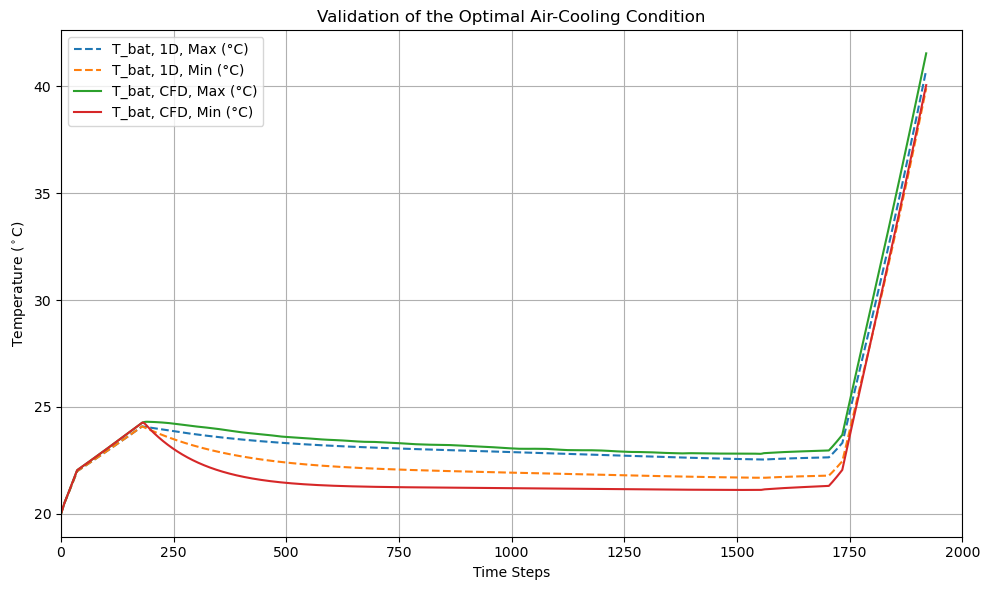

Saved temperature-curve figure: d:\Users\liu\Desktop\eBATS_scanned_final\out\C0008\C0008R00_PARK25_AC_1D_VAL.png


In [27]:
# plot and save the 1D and CFD maximum/minimum battery-temperature curves
# The plotting style follows the reference notebook BTMS T Solver(17).ipynb.

os.makedirs(OUTPUT_DIR, exist_ok=True)
figure_path = os.path.join(OUTPUT_DIR, RESULT_FIGURE_NAME)

# Use the same basic Matplotlib style as the reference program.
plt.rcdefaults()
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10, 6))

# 1D model results: dashed curves
plt.plot(
    results['time_s'],
    results['Tmax_C'],
    linestyle='--',
    label='T_bat, 1D, Max (°C)'
)
plt.plot(
    results['time_s'],
    results['Tmin_C'],
    linestyle='--',
    label='T_bat, 1D, Min (°C)'
)

# CFD results: solid curves
plt.plot(
    cfd_temperature_data['CFD_max']['time_s'],
    cfd_temperature_data['CFD_max']['temperature_C'],
    label='T_bat, CFD, Max (°C)'
)
plt.plot(
    cfd_temperature_data['CFD_min']['time_s'],
    cfd_temperature_data['CFD_min']['temperature_C'],
    label='T_bat, CFD, Min (°C)'
)

plt.xlabel('Time Steps')
plt.ylabel(r'Temperature ($^\circ$C)')
plt.title('Validation of the Optimal Air-Cooling Condition')
plt.xlim(0.0, 2000.0)
plt.legend()
plt.grid()
plt.tight_layout()

plt.savefig(
    figure_path,
    dpi=600,
    bbox_inches='tight'
)
plt.show()

print(f'Saved temperature-curve figure: {figure_path}')
